In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

In [3]:
print(torch.__version__)
print(torchvision.__version__)

2.8.0+cu126
0.23.0+cu126


In [4]:
#get the train and test data
#get the train data
train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(), 
    target_transform=None)
#get the test data
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None)

100.0%
100.0%
100.0%
100.0%


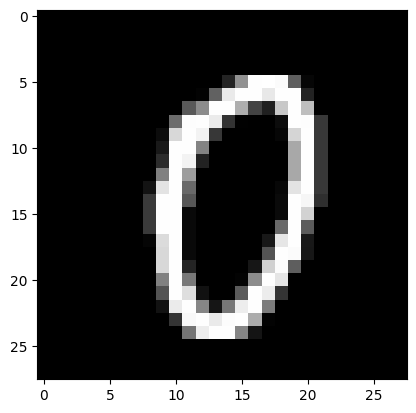

In [5]:
#visualize
#reshape train data
reshaped_ex = train_data[1000][0].reshape(28,28)
#visualize it
plt.imshow(reshaped_ex, cmap='gray')

In [6]:
#class name of the data
class_name = train_data.classes
class_name

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [7]:
#prepare data with DataLoader
#import DataLoader
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_data, batch_size = 32, shuffle=True)
#doesnt have to shuffle the data
test_dataloader = DataLoader(test_data, batch_size = 32, shuffle=False)

In [8]:
#print out the first batch and its labels
train_features, train_labels = next(iter(train_dataloader))
train_features.size(), train_labels.size()

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [11]:
#build the baseline model first
class MNISTV0(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )
    def forward(self, x:torch.Tensor):
        return self.layer(x)

In [12]:
model_0 = MNISTV0(input_shape=28*28, hidden_units = 10, output_shape=10)
model_0

MNISTV0(
  (layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [16]:
#setup loss, optimizer, and accuracy
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(),
                         lr = 1e-1)
from torchmetrics import Accuracy
accuracy = Accuracy(task='multiclass', num_classes = len(class_name))

In [25]:
#create train_step and test_step
# def train_step(model, dataloader, loss_fn, optimizer, accuracy):
#     model.train()
#     accuracy.reset()
#     train_loss, train_acc = 0, 0
#     for X,y in dataloader:
        
#         train_logits = model(X)
#         loss = loss_fn(train_logits, y)        
#         acc = accuracy(train_logits.argmax(dim=1), y)
#         train_loss += loss
#         train_acc += acc
        

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#     train_loss /= len(dataloader)
#     train_acc /= len(dataloader)
    
#     print(f"train_loss : {train_loss} |train_acc : {train_acc*100}")
def train_step(model, dataloader, loss_fn, optimizer, accuracy):
    model.train()
    accuracy.reset()
    train_loss, train_acc = 0, 0

    for X, y in dataloader:
        logits = model(X)
        loss = loss_fn(logits, y)
        acc = accuracy(logits.argmax(dim=1), y)

        train_loss += loss.item()
        train_acc  += acc.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(dataloader)
    train_acc  /= len(dataloader)
    print(f"train_loss: {train_loss:.4f} | train_acc: {train_acc*100:.2f}%")
# def test_step(model, dataloader, loss_fn, accuracy):
#     model.eval()
#     accuracy.reset()
#     test_loss, test_acc = 0, 0
#     with torch.inference_mode():
#         for X, y in dataloader:
#             test_logits = model(X)
#             loss = loss_fn(test_logits, y)
#             test_loss += loss
#             acc = accuracy(test_logits.argmax(dim=1), y)
#             test_acc += acc
#         test_loss /= len(dataloader)
#         test_acc /= len(dataloader)
    
#     print(f"test loss : {test_loss} |test acc : {test_acc*100}")
def test_step(model, dataloader, loss_fn, accuracy):
    model.eval()
    accuracy.reset()
    test_loss, test_acc = 0, 0

    with torch.inference_mode():
        for X, y in dataloader:
            logits = model(X)
            loss = loss_fn(logits, y)
            acc = accuracy(logits.argmax(dim=1), y)

            test_loss += loss.item()
            test_acc  += acc.item()

    test_loss /= len(dataloader)
    test_acc  /= len(dataloader)
    print(f"test_loss: {test_loss:.4f} | test_acc: {test_acc*100:.2f}%")


In [27]:
#setup seed
torch.manual_seed(42)

epochs = 3
for epoch in range(epochs):
    train_step(model_0, train_dataloader, loss_fn, optimizer, accuracy)
    test_step(model_0, test_dataloader, loss_fn, accuracy)

train_loss: 0.2651 | train_acc: 92.42%
test_loss: 0.2450 | test_acc: 92.82%
train_loss: 0.2490 | train_acc: 92.79%
test_loss: 0.2397 | test_acc: 93.11%
train_loss: 0.2380 | train_acc: 93.11%
test_loss: 0.2353 | test_acc: 93.40%
